<a href="https://colab.research.google.com/github/ChiNonsoHenry16/Blood-Transfusion-and-AI-Models/blob/main/Predicting_Post_transfucion_Systolic_Blood_Pressure_and_Body_Temperature_using_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating Simulated Data on Blood Transfusion

In [1]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Number of synthetic patients
n_samples = 1000

# Generate demographics
ages = np.random.randint(18, 90, size=n_samples)
sexes = np.random.choice(['Male', 'Female'], size=n_samples, p=[0.5, 0.5])

# Generate hemoglobin levels (g/dL)
hemoglobin = np.random.normal(12.5 - (ages - 50) * 0.02, 1.2, n_samples).clip(7, 17)

# Transfused product type — ensure at least one of each
product_types = np.random.choice(['RBC', 'Platelets', 'Plasma'], size=n_samples - 3, p=[0.7, 0.2, 0.1])
# Force inclusion
product_types = np.append(product_types, ['RBC', 'Platelets', 'Plasma'])
np.random.shuffle(product_types)

# Pre transfusion vitals
pre_sbp = np.random.normal(120, 15, n_samples).clip(90, 180)
pre_temp = np.random.normal(36.8, 0.4, n_samples).clip(35.5, 38.5)

# Post transfusion vitals & reaction outcome
reaction_outcome = []
post_sbp = []
post_temp = []

for i in range(n_samples):
    sbp = pre_sbp[i]
    temp = pre_temp[i]
    hb = hemoglobin[i]
    product = product_types[i]

    risk = 0
    if hb < 9:
        risk += 0.2
    if product == 'Platelets':
        risk += 0.2
    if ages[i] > 70:
        risk += 0.1

    prob = min(0.1 + risk, 0.8)
    outcome = np.random.choice(['None', 'Mild', 'Moderate', 'Severe'], p=[1-prob, prob*0.7, prob*0.25, prob*0.05])
    reaction_outcome.append(outcome)

    if outcome == 'None':
        sbp_post = sbp + np.random.normal(0, 2)
        temp_post = temp + np.random.normal(0, 0.1)
    elif outcome == 'Mild':
        sbp_post = sbp - np.random.normal(5, 3)
        temp_post = temp + np.random.normal(0.5, 0.2)
    elif outcome == 'Moderate':
        sbp_post = sbp - np.random.normal(10, 5)
        temp_post = temp + np.random.normal(1.0, 0.3)
    else:
        sbp_post = sbp - np.random.normal(20, 5)
        temp_post = temp + np.random.normal(1.5, 0.5)

    post_sbp.append(sbp_post)
    post_temp.append(temp_post)

# Build DataFrame
df = pd.DataFrame({
    'Age': ages,
    'Sex': sexes,
    'Hemoglobin': hemoglobin.round(1),
    'Product_Type': product_types,
    'Pre_SBP': pre_sbp.round(1),
    'Pre_Temp': pre_temp.round(1),
    'Post_SBP': np.array(post_sbp).round(1),
    'Post_Temp': np.array(post_temp).round(1),
    'Reaction_Outcome': reaction_outcome
})

print(df['Product_Type'].value_counts())  # Confirm all 3 exist
df.head()


Product_Type
RBC          694
Platelets    214
Plasma        92
Name: count, dtype: int64


,Age,Sex,Hemoglobin,Product_Type,Pre_SBP,Pre_Temp,Post_SBP,Post_Temp,Reaction_Outcome
0,69,Female,12.9,RBC,152.0,36.1,150.5,36.0,None
1,32,Male,14.6,RBC,101.0,36.8,98.6,36.7,None
2,89,Female,11.9,RBC,106.0,36.8,106.2,36.8,None
3,78,Male,10.9,RBC,129.2,36.8,129.8,36.8,None
4,38,Male,12.5,RBC,138.8,36.9,137.5,36.7,None


In [3]:
# Setup
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Use your dataframe 'df'
print(df.head())

# Explicitly set Product_Type as categorical with all levels:
df['Product_Type'] = pd.Categorical(df['Product_Type'], categories=['RBC', 'Platelets', 'Plasma'])

df_encoded = pd.get_dummies(df, columns=['Product_Type'], drop_first=True)
print(df_encoded.columns)


   Age     Sex  Hemoglobin Product_Type  Pre_SBP  Pre_Temp  Post_SBP  \
0   69  Female        12.9          RBC    152.0      36.1     150.5   
1   32    Male        14.6          RBC    101.0      36.8      98.6   
2   89  Female        11.9          RBC    106.0      36.8     106.2   
3   78    Male        10.9          RBC    129.2      36.8     129.8   
4   38    Male        12.5          RBC    138.8      36.9     137.5   

   Post_Temp Reaction_Outcome  
0       36.0             None  
1       36.7             None  
2       36.8             None  
3       36.8             None  
4       36.7             None  
Index(['Age', 'Sex', 'Hemoglobin', 'Pre_SBP', 'Pre_Temp', 'Post_SBP',
       'Post_Temp', 'Reaction_Outcome', 'Product_Type_Platelets',
       'Product_Type_Plasma'],
      dtype='object')


In [5]:
# Use only the dummies that actually exist — guaranteed by Categorical
X_sbp = df_encoded[['Pre_SBP', 'Hemoglobin', 'Age',
                    'Product_Type_Platelets', 'Product_Type_Plasma']]
y_sbp = df_encoded['Post_SBP']

X_temp = df_encoded[['Pre_Temp', 'Hemoglobin', 'Age',
                     'Product_Type_Platelets', 'Product_Type_Plasma']]
y_temp = df_encoded['Post_Temp']

Generating the error values alone

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Optional XGBoost import
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print("XGBoost not installed; skipping XGBRegressor.")

# Prepare data splits for Post_SBP
X_train_sbp, X_test_sbp, y_train_sbp, y_test_sbp = train_test_split(
    X_sbp, y_sbp, test_size=0.2, random_state=42)

# Prepare data splits for Post_Temp
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42)

# Models dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Lasso Regression": Lasso(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)

def evaluate_models(X_train, X_test, y_train, y_test, target_name):
    print(f"\n--- Evaluating models for {target_name} ---")
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = mse ** 0.5
        r2 = r2_score(y_test, y_pred)
        print(f"{name:20} | MSE: {mse:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}")

# Evaluate all models for Post_SBP
evaluate_models(X_train_sbp, X_test_sbp, y_train_sbp, y_test_sbp, "Post_SBP")

# Evaluate all models for Post_Temp
evaluate_models(X_train_temp, X_test_temp, y_train_temp, y_test_temp, "Post_Temp")



--- Evaluating models for Post_SBP ---
Linear Regression    | MSE: 20.090 | RMSE: 4.482 | R2: 0.916
Ridge Regression     | MSE: 20.087 | RMSE: 4.482 | R2: 0.916
Lasso Regression     | MSE: 20.296 | RMSE: 4.505 | R2: 0.915
Decision Tree        | MSE: 28.544 | RMSE: 5.343 | R2: 0.881
Random Forest        | MSE: 22.909 | RMSE: 4.786 | R2: 0.904
Gradient Boosting    | MSE: 20.865 | RMSE: 4.568 | R2: 0.913
AdaBoost             | MSE: 25.962 | RMSE: 5.095 | R2: 0.892
KNN                  | MSE: 23.749 | RMSE: 4.873 | R2: 0.901
SVR                  | MSE: 25.646 | RMSE: 5.064 | R2: 0.893
XGBoost              | MSE: 24.872 | RMSE: 4.987 | R2: 0.896

--- Evaluating models for Post_Temp ---
Linear Regression    | MSE: 0.114 | RMSE: 0.337 | R2: 0.558
Ridge Regression     | MSE: 0.114 | RMSE: 0.337 | R2: 0.558
Lasso Regression     | MSE: 0.259 | RMSE: 0.509 | R2: -0.007
Decision Tree        | MSE: 0.214 | RMSE: 0.462 | R2: 0.169
Random Forest        | MSE: 0.125 | RMSE: 0.353 | R2: 0.516
Gradient

Plotting Scatter Plots for all Individual ML Models




--- Evaluating models for Post_SBP ---

Error Metrics Table:

                 Model       MSE     RMSE       R2
      Ridge Regression 20.087197 4.481874 0.916149
     Linear Regression 20.090085 4.482196 0.916137
      Lasso Regression 20.295706 4.505076 0.915279
     Gradient Boosting 20.864811 4.567802 0.912903
         Random Forest 22.909354 4.786372 0.904368
                   KNN 23.748902 4.873285 0.900864
Hist Gradient Boosting 24.058230 4.904919 0.899573
               XGBoost 24.872032 4.987187 0.896175
                   SVR 25.646182 5.064206 0.892944
              AdaBoost 25.961987 5.095291 0.891626
         Decision Tree 28.544300 5.342687 0.880846


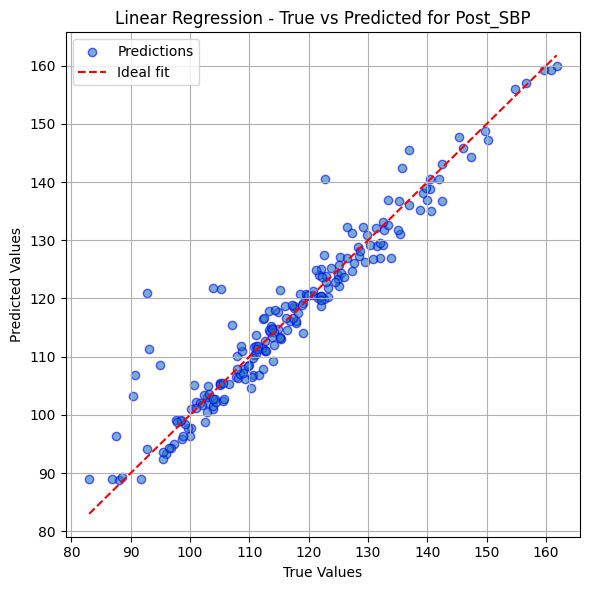

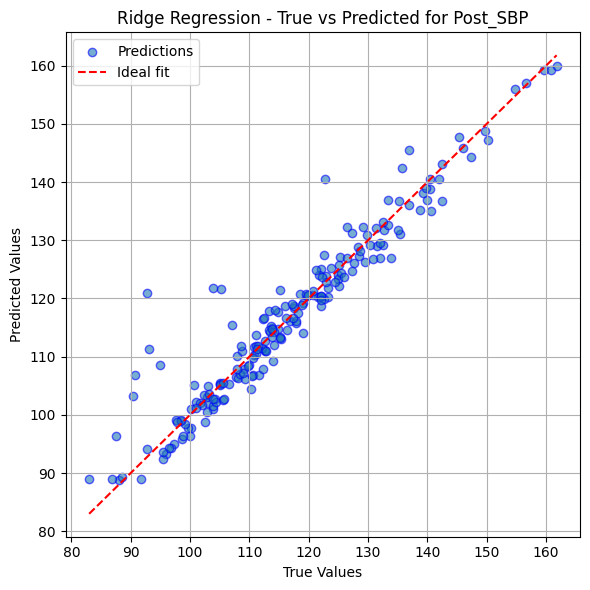

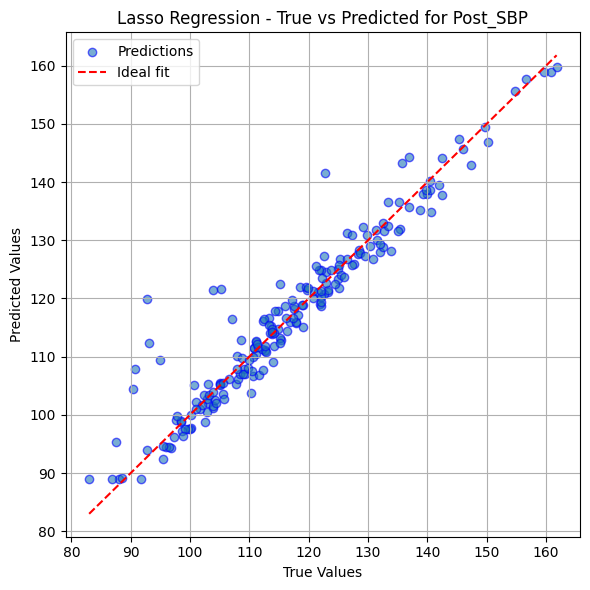

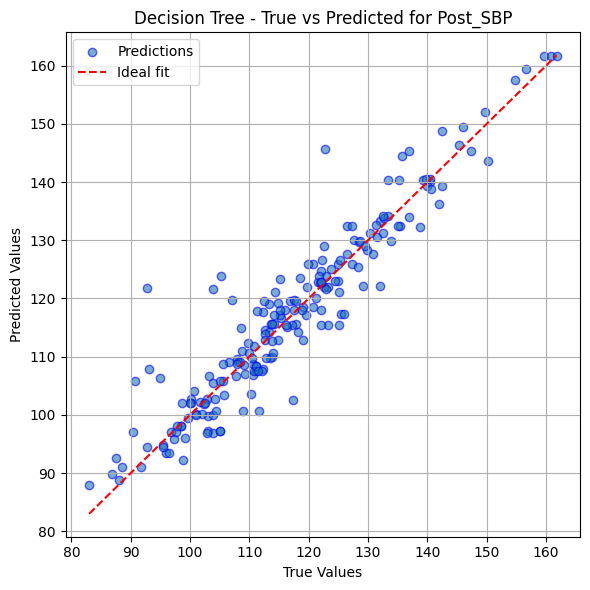

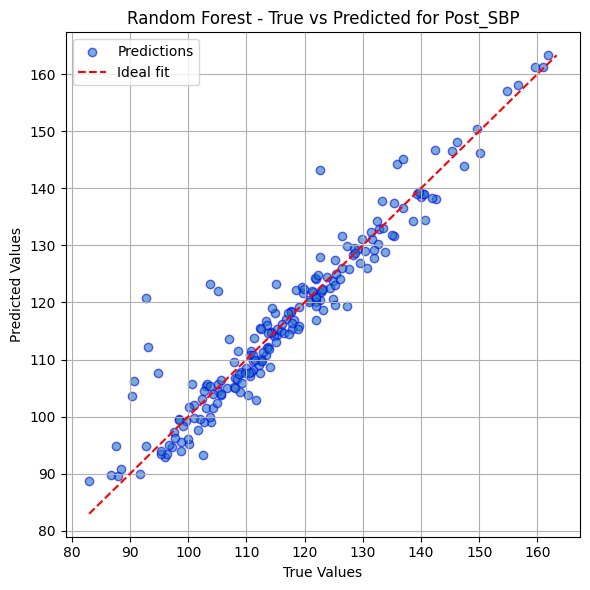

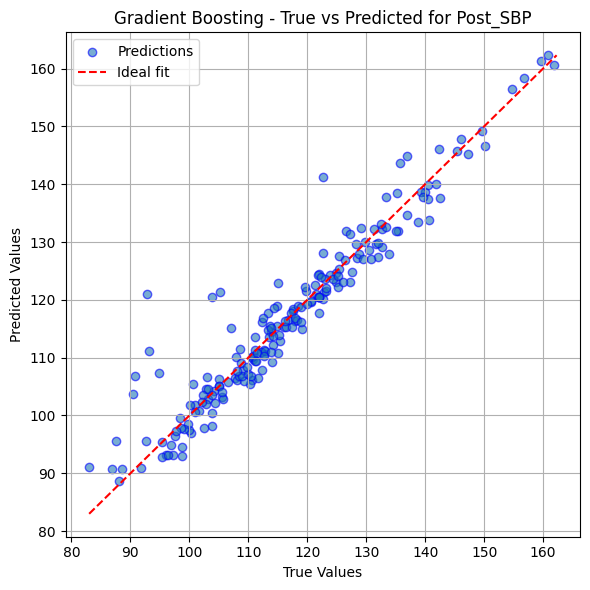

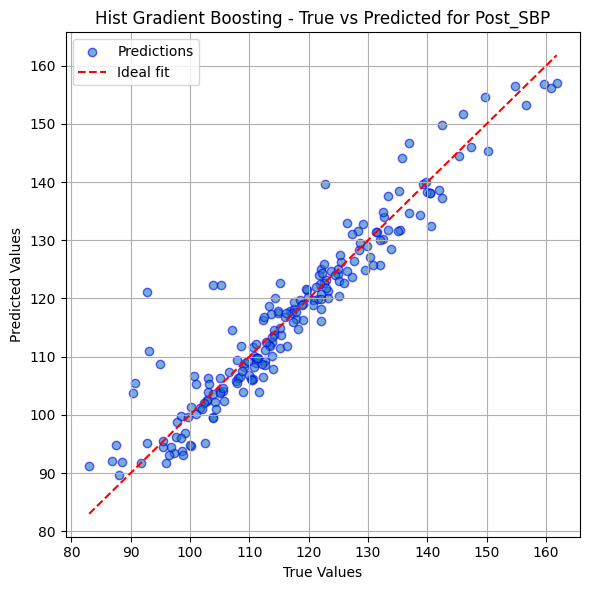

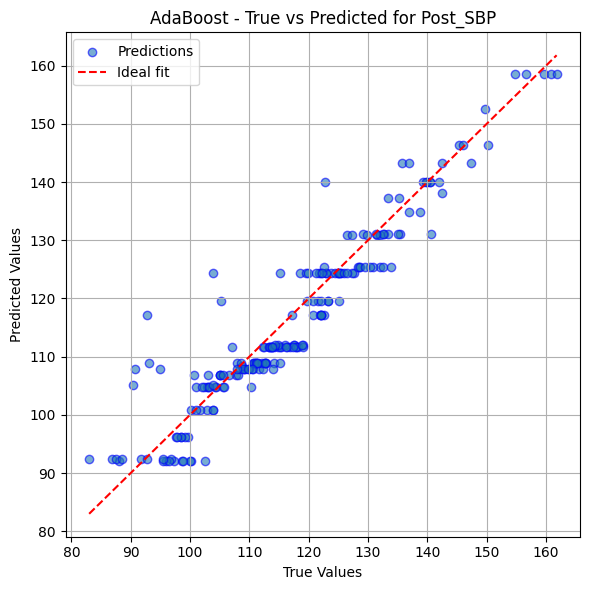

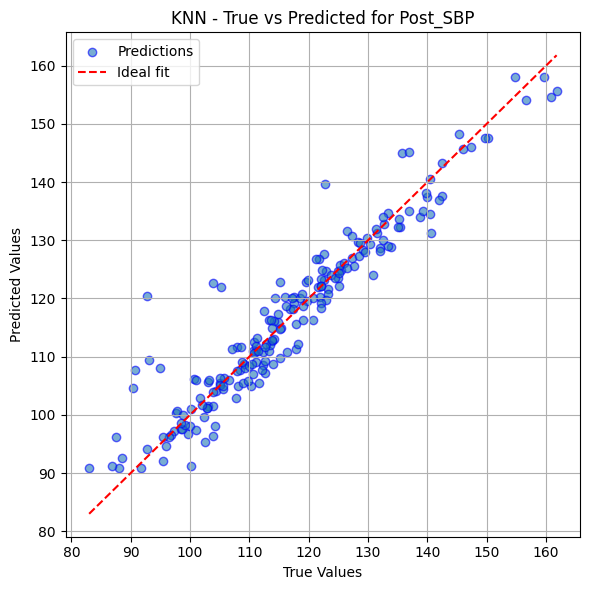

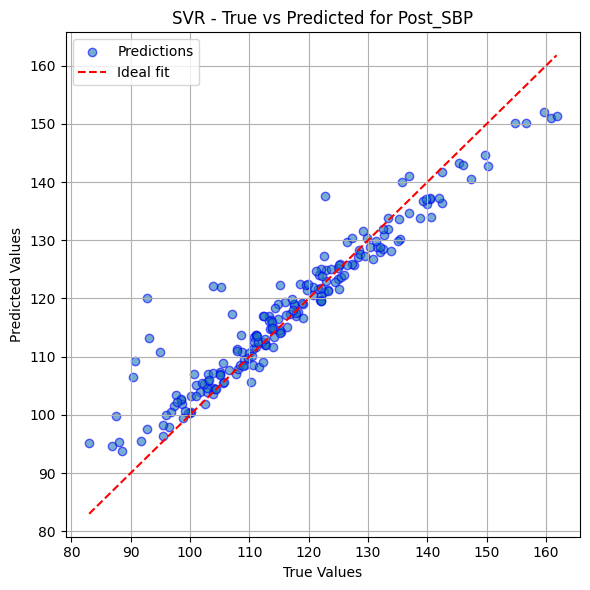

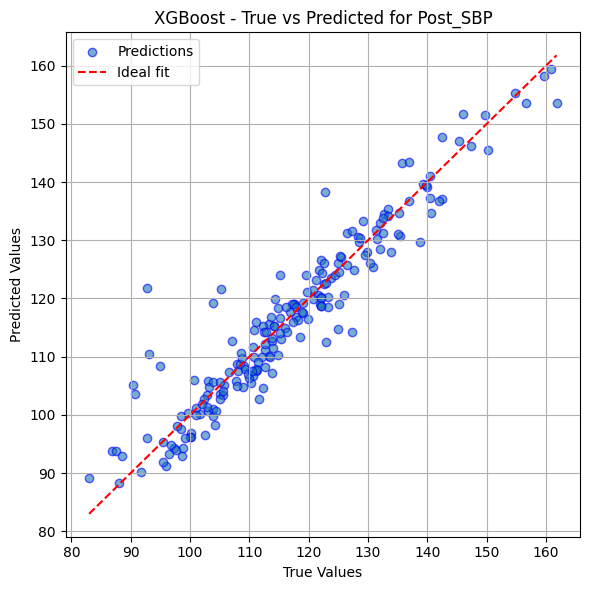


--- Evaluating models for Post_Temp ---

Error Metrics Table:

                 Model      MSE     RMSE        R2
      Ridge Regression 0.113719 0.337223  0.557910
     Linear Regression 0.113733 0.337244  0.557855
     Gradient Boosting 0.116868 0.341860  0.545669
         Random Forest 0.124626 0.353024  0.515509
Hist Gradient Boosting 0.127536 0.357122  0.504197
               XGBoost 0.142214 0.377112  0.447137
              AdaBoost 0.154792 0.393437  0.398236
         Decision Tree 0.213800 0.462385  0.168840
                   SVR 0.227781 0.477264  0.114490
                   KNN 0.230548 0.480154  0.103732
      Lasso Regression 0.259016 0.508936 -0.006940


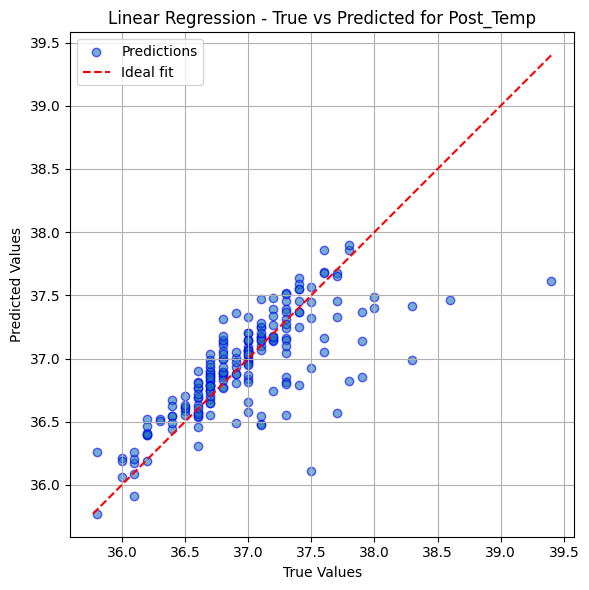

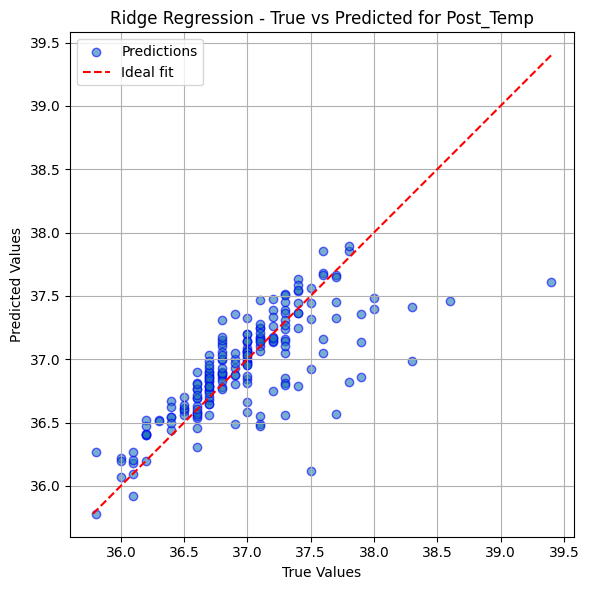

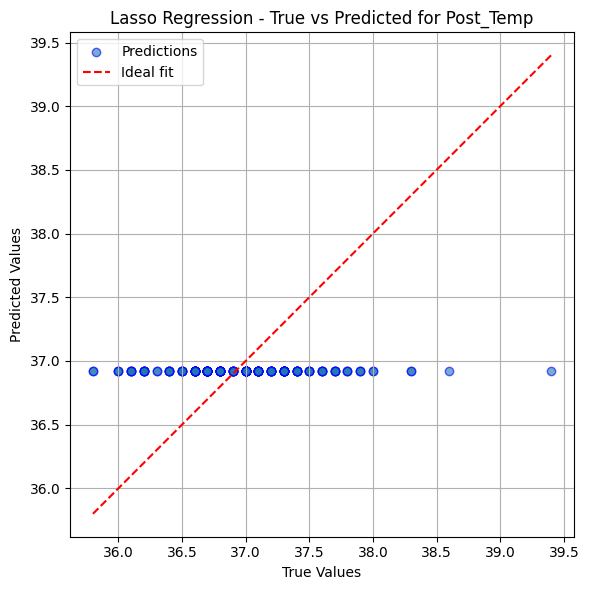

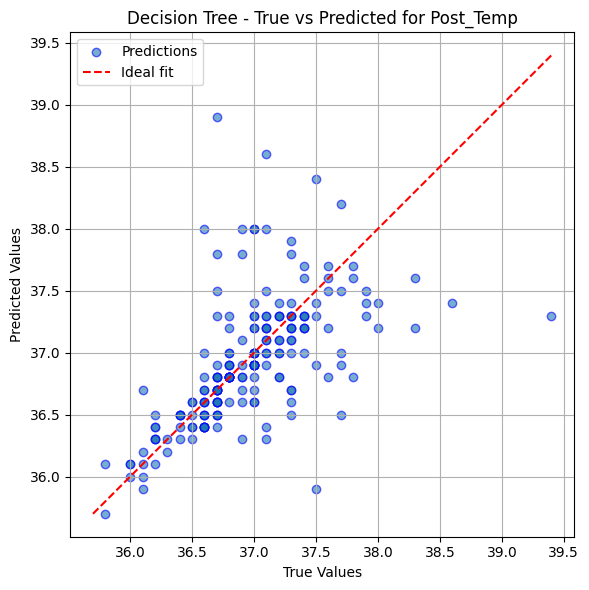

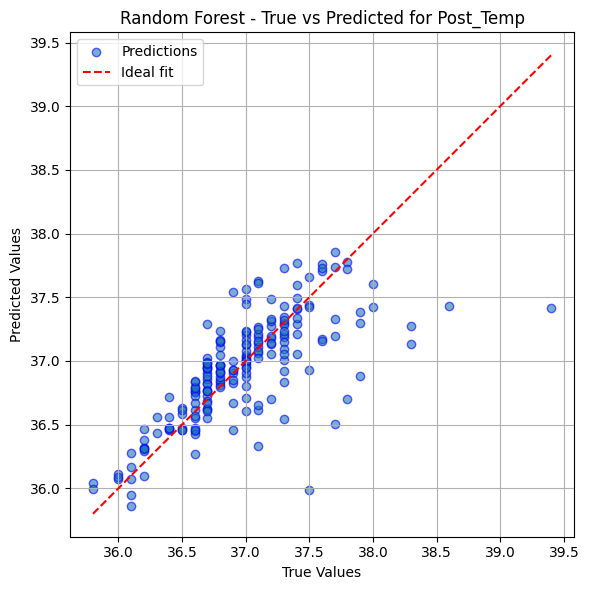

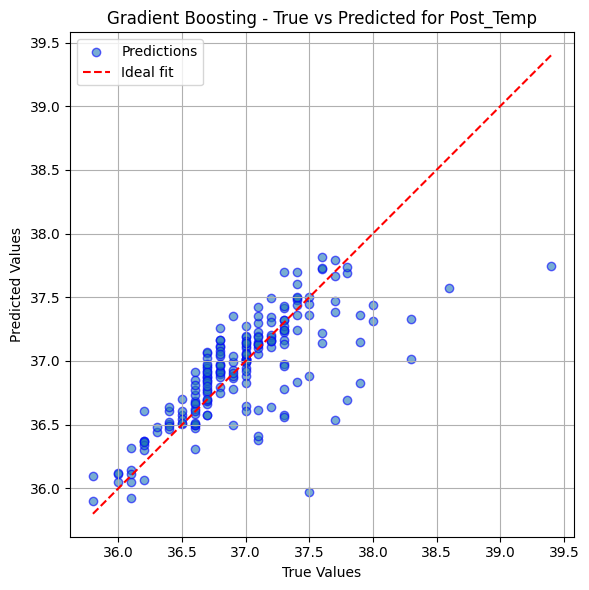

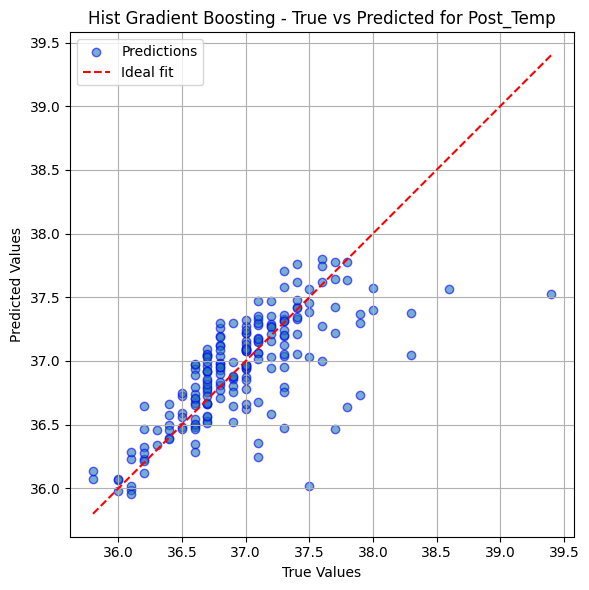

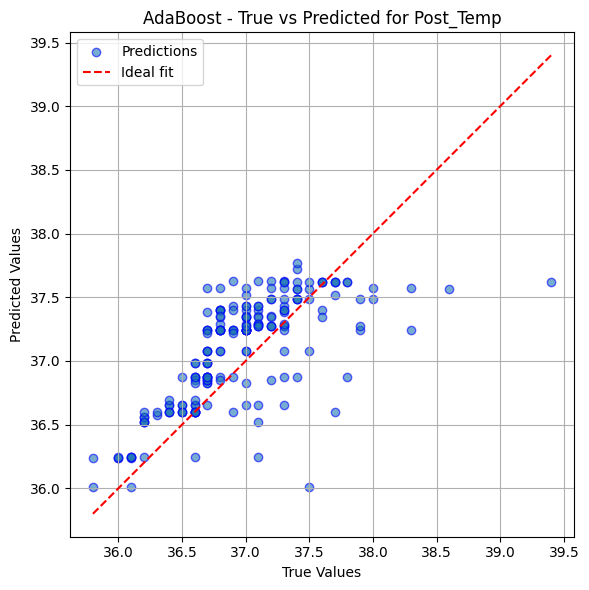

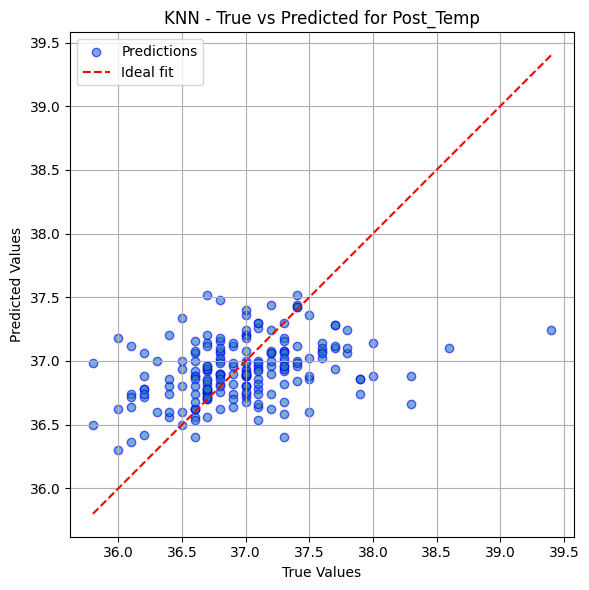

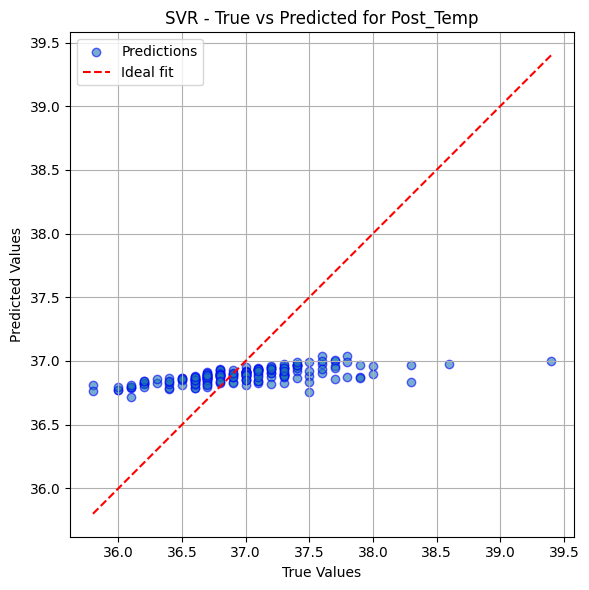

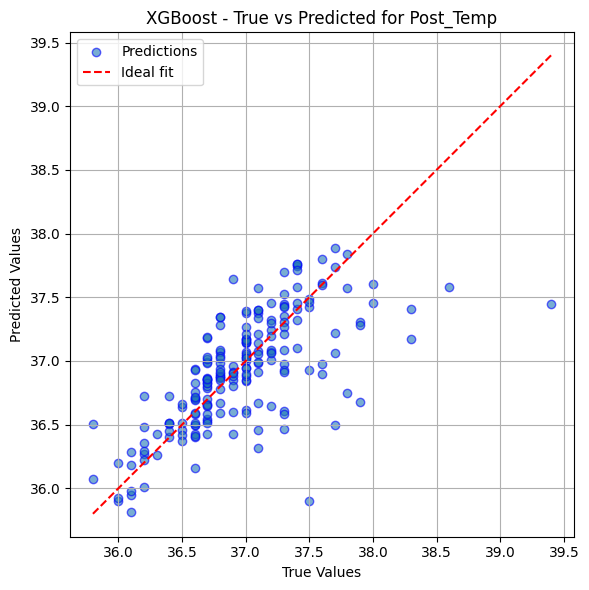

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Optional XGBoost import
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print("⚠️ XGBoost not installed; skipping XGBRegressor.")

# Prepare data splits for Post_SBP
X_train_sbp, X_test_sbp, y_train_sbp, y_test_sbp = train_test_split(
    X_sbp, y_sbp, test_size=0.2, random_state=42)

# Prepare data splits for Post_Temp
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42)

# Models dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Lasso Regression": Lasso(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(max_iter=100, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)

def evaluate_models(X_train, X_test, y_train, y_test, target_name):
    print(f"\n--- Evaluating models for {target_name} ---")
    results = []

    # Store all predictions too, for plotting later
    predictions = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        results.append({
            'Model': name,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
        predictions[name] = y_pred

    # Create and print a table of results
    results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
    print("\nError Metrics Table:\n")
    print(results_df.to_string(index=False))

    # Then plot true vs predicted for each model
    for name in predictions:
        y_pred = predictions[name]
        plt.figure(figsize=(6, 6))
        plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='b', label='Predictions')
        min_val = min(min(y_test), min(y_pred))
        max_val = max(max(y_test), max(y_pred))
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal fit')
        plt.xlabel('True Values')
        plt.ylabel('Predicted Values')
        plt.title(f"{name} - True vs Predicted for {target_name}")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Evaluate all models for Post_SBP
evaluate_models(X_train_sbp, X_test_sbp, y_train_sbp, y_test_sbp, "Post_SBP")

# Evaluate all models for Post_Temp
evaluate_models(X_train_temp, X_test_temp, y_train_temp, y_test_temp, "Post_Temp")


One Scatter PLot for all the Models


--- Evaluating models for Post_SBP ---

Error Metrics Table:

                 Model       MSE     RMSE       R2
      Ridge Regression 20.087197 4.481874 0.916149
     Linear Regression 20.090085 4.482196 0.916137
      Lasso Regression 20.295706 4.505076 0.915279
     Gradient Boosting 20.864811 4.567802 0.912903
         Random Forest 22.909354 4.786372 0.904368
                   KNN 23.748902 4.873285 0.900864
Hist Gradient Boosting 24.058230 4.904919 0.899573
               XGBoost 24.872032 4.987187 0.896175
                   SVR 25.646182 5.064206 0.892944
              AdaBoost 25.961987 5.095291 0.891626
         Decision Tree 28.544300 5.342687 0.880846


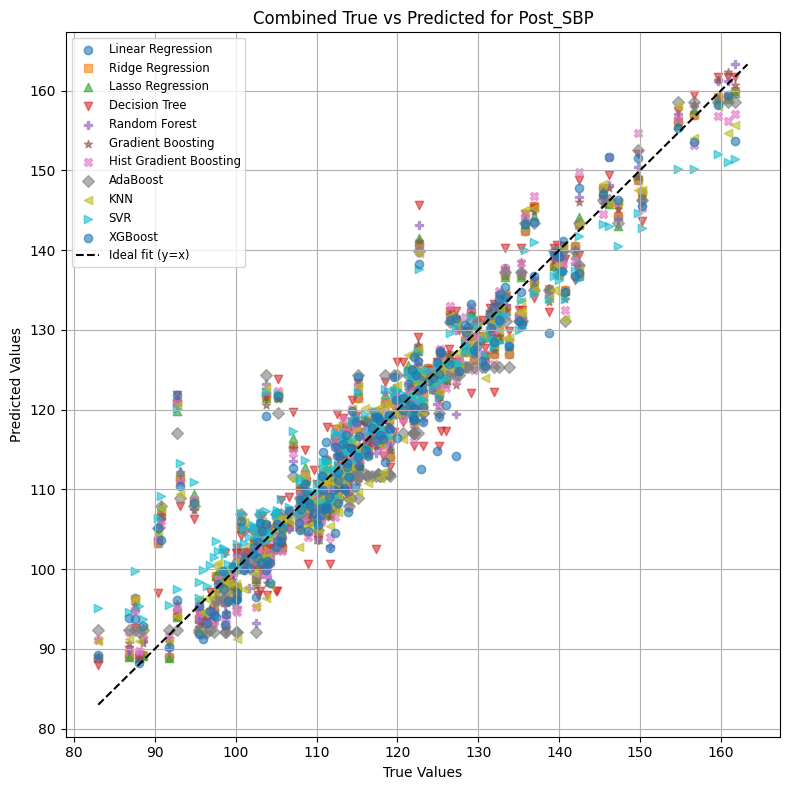


--- Evaluating models for Post_Temp ---

Error Metrics Table:

                 Model      MSE     RMSE        R2
      Ridge Regression 0.113719 0.337223  0.557910
     Linear Regression 0.113733 0.337244  0.557855
     Gradient Boosting 0.116868 0.341860  0.545669
         Random Forest 0.124626 0.353024  0.515509
Hist Gradient Boosting 0.127536 0.357122  0.504197
               XGBoost 0.142214 0.377112  0.447137
              AdaBoost 0.154792 0.393437  0.398236
         Decision Tree 0.213800 0.462385  0.168840
                   SVR 0.227781 0.477264  0.114490
                   KNN 0.230548 0.480154  0.103732
      Lasso Regression 0.259016 0.508936 -0.006940


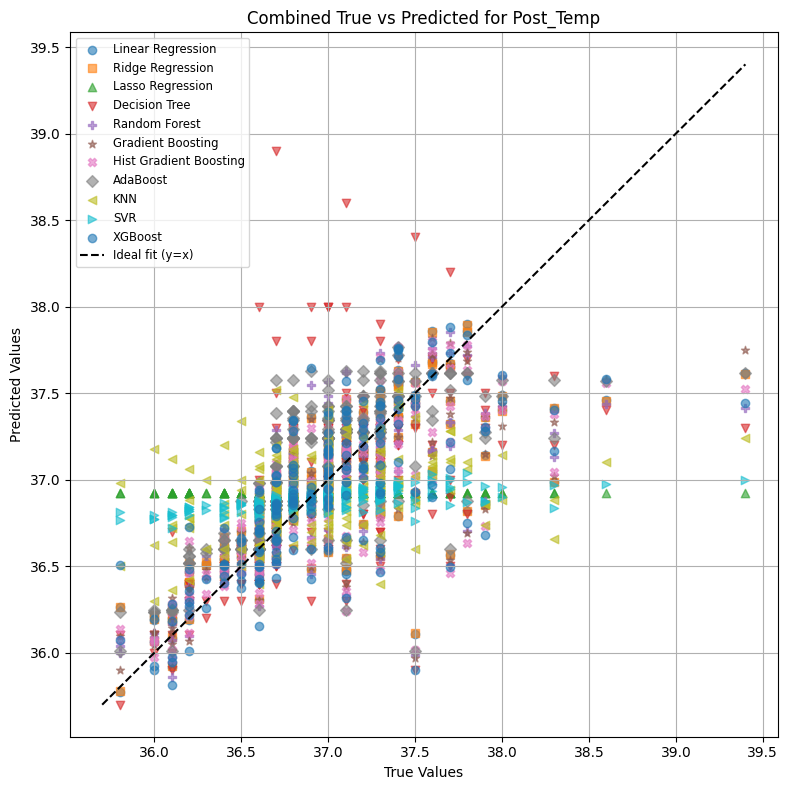

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Optional XGBoost import
try:
    from xgboost import XGBRegressor
    xgb_available = True
except ImportError:
    xgb_available = False
    print("⚠️ XGBoost not installed; skipping XGBRegressor.")

# --- Prepare data splits for Post_SBP ---
X_train_sbp, X_test_sbp, y_train_sbp, y_test_sbp = train_test_split(
    X_sbp, y_sbp, test_size=0.2, random_state=42)

# --- Prepare data splits for Post_Temp ---
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42)

# --- Models dictionary ---
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Lasso Regression": Lasso(random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(max_iter=100, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
}

if xgb_available:
    models["XGBoost"] = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)


def evaluate_models(X_train, X_test, y_train, y_test, target_name):
    print(f"\n--- Evaluating models for {target_name} ---")
    results = []
    predictions = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        results.append({
            'Model': name,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
        predictions[name] = y_pred

    # Show table
    results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
    print("\nError Metrics Table:\n")
    print(results_df.to_string(index=False))

    # One combined scatter plot
    plt.figure(figsize=(8, 8))
    markers = ['o', 's', '^', 'v', 'P', '*', 'X', 'D', '<', '>']
    colors = plt.cm.tab10.colors  # up to 10 colors

    for idx, (name, y_pred) in enumerate(predictions.items()):
        plt.scatter(y_test, y_pred,
                    alpha=0.6,
                    marker=markers[idx % len(markers)],
                    color=colors[idx % len(colors)],
                    label=name)

    # y = x line
    min_val = min(min(y_test), min(min(y_pred) for y_pred in predictions.values()))
    max_val = max(max(y_test), max(max(y_pred) for y_pred in predictions.values()))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal fit (y=x)')

    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title(f"Combined True vs Predicted for {target_name}")
    plt.legend(loc='best', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# --- Evaluate all models for Post_SBP ---
evaluate_models(X_train_sbp, X_test_sbp, y_train_sbp, y_test_sbp, "Post_SBP")

# --- Evaluate all models for Post_Temp ---
evaluate_models(X_train_temp, X_test_temp, y_train_temp, y_test_temp, "Post_Temp")


# Ensemble Models

In [14]:
from sklearn.ensemble import (
    BaggingRegressor,
    ExtraTreesRegressor,
    StackingRegressor,
    VotingRegressor
)

# Simple base learners for stacking
base_learners = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50, random_state=42))
]

stacking = StackingRegressor(estimators=base_learners, final_estimator=Ridge())

voting = VotingRegressor(estimators=[
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=50, random_state=42))
])

# Add new ensemble models to your dictionary:
models.update({
    "Bagging": BaggingRegressor(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "Stacking": stacking,
    "Voting": voting
})

# Optional: add LightGBM if available
try:
    from lightgbm import LGBMRegressor
    models["LightGBM"] = LGBMRegressor(n_estimators=100, random_state=42)
except ImportError:
    print("⚠️ LightGBM not installed; skipping LightGBM.")



--- Evaluating models for Post_SBP ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 388
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 5
[LightGBM] [Info] Start training from score 119.362750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

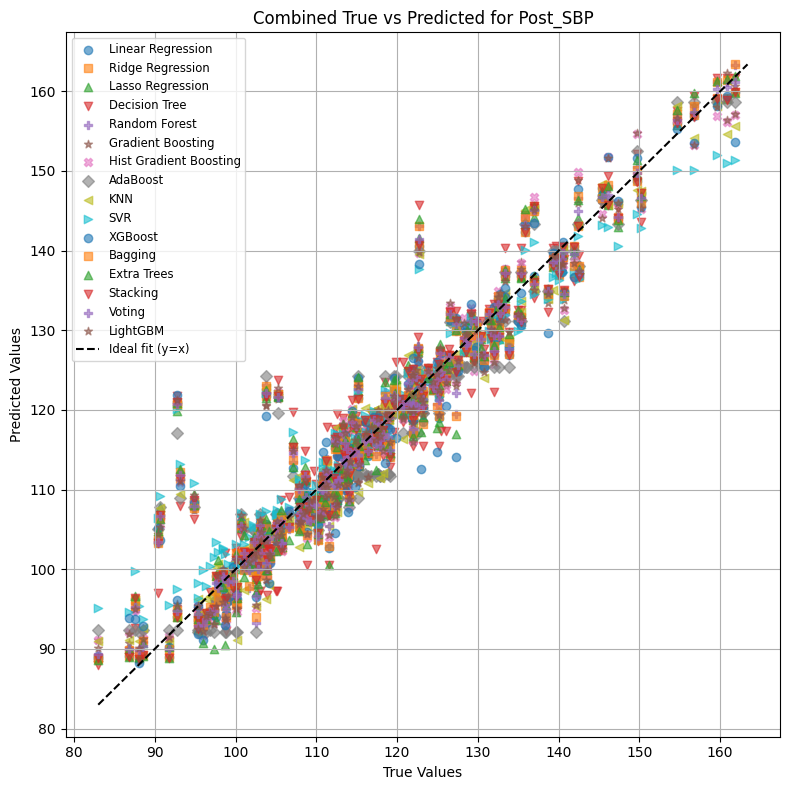


--- Evaluating models for Post_Temp ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 158
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 5
[LightGBM] [Info] Start training from score 36.920750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

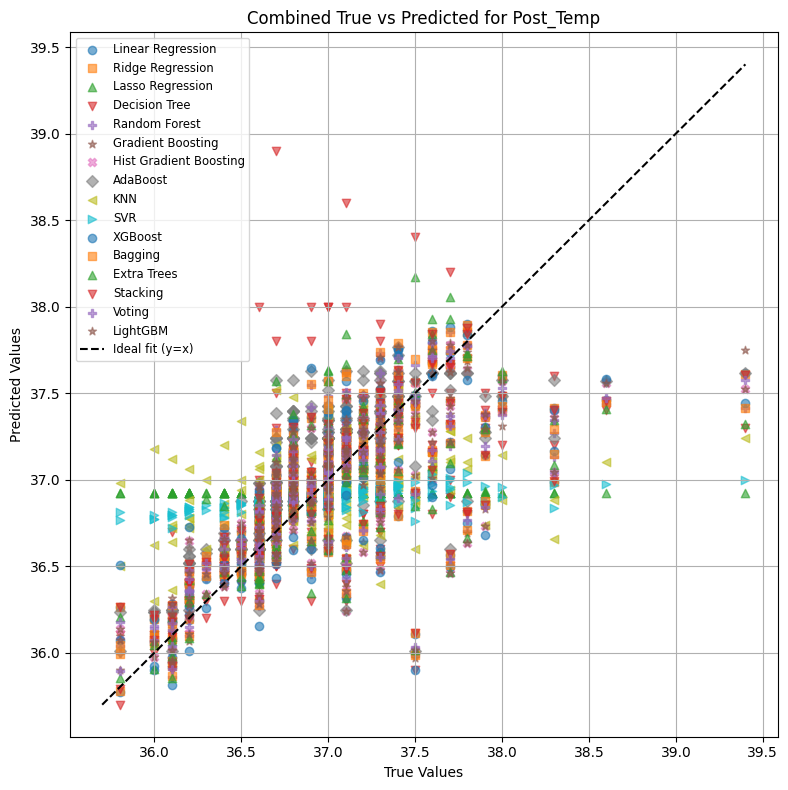

In [15]:
# Evaluate with the extended models
evaluate_models(X_train_sbp, X_test_sbp, y_train_sbp, y_test_sbp, "Post_SBP")
evaluate_models(X_train_temp, X_test_temp, y_train_temp, y_test_temp, "Post_Temp")



In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_and_plot_models(X_train, X_test, y_train, y_test, target_name, top_n_for_scatter=5):
    """
    Evaluates all models, prints a clean table,
    plots a bar chart of R²,
    and plots a single scatter plot for top N models.
    """
    results = []
    predictions = {}

    # Fit all models & collect results
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'R2': r2})
        predictions[name] = y_pred

    # Make results DataFrame
    results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
    print(f"\n=== Error Metrics for {target_name} ===")
    print(results_df.to_string(index=False))

    # Bar plot for R² comparison
    plt.figure(figsize=(10, 5))
    plt.barh(results_df['Model'], results_df['R2'], color='skyblue')
    plt.xlabel("R² Score")
    plt.title(f"R² Comparison for {target_name}")
    plt.gca().invert_yaxis()  # best at top
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

    # Combined scatter plot for top N models only
    plt.figure(figsize=(8, 8))
    colors = plt.cm.tab10.colors
    markers = ['o', 's', '^', 'v', 'P', '*', 'X', 'D', '<', '>']

    # Take top N models
    top_models = results_df.head(top_n_for_scatter)['Model']

    for idx, model_name in enumerate(top_models):
        plt.scatter(y_test, predictions[model_name],
                    alpha=0.7,
                    color=colors[idx % len(colors)],
                    marker=markers[idx % len(markers)],
                    label=model_name)

    min_val = min(min(y_test), min(min(predictions[m]) for m in top_models))
    max_val = max(max(y_test), max(max(predictions[m]) for m in top_models))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal fit (y=x)')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title(f"True vs Predicted (Top {top_n_for_scatter} Models) for {target_name}")
    plt.legend(loc='best', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 388
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 5
[LightGBM] [Info] Start training from score 119.362750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

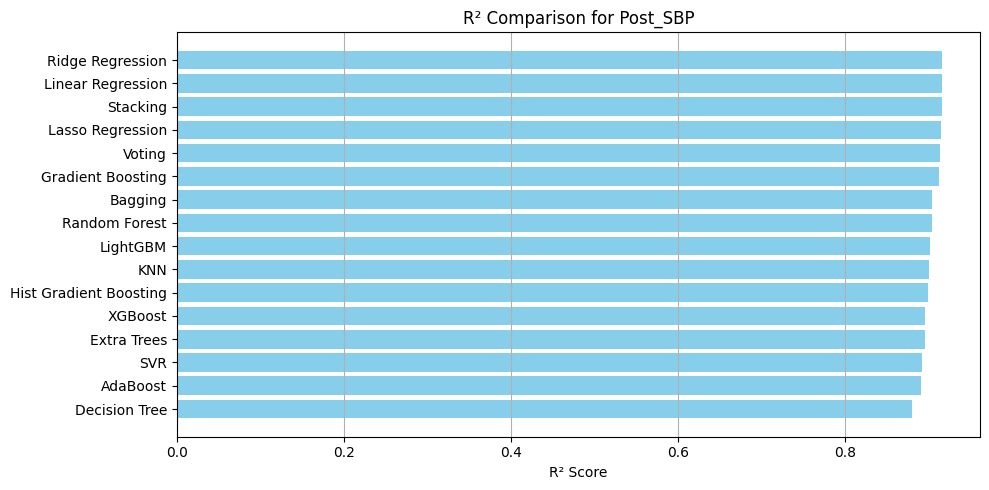

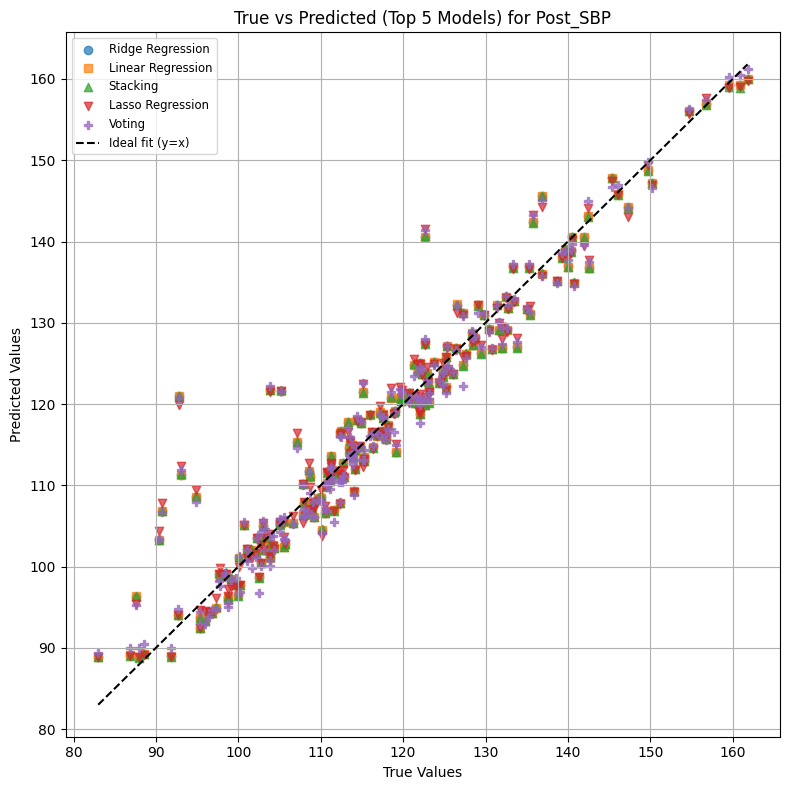

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000059 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 158
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 5
[LightGBM] [Info] Start training from score 36.920750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

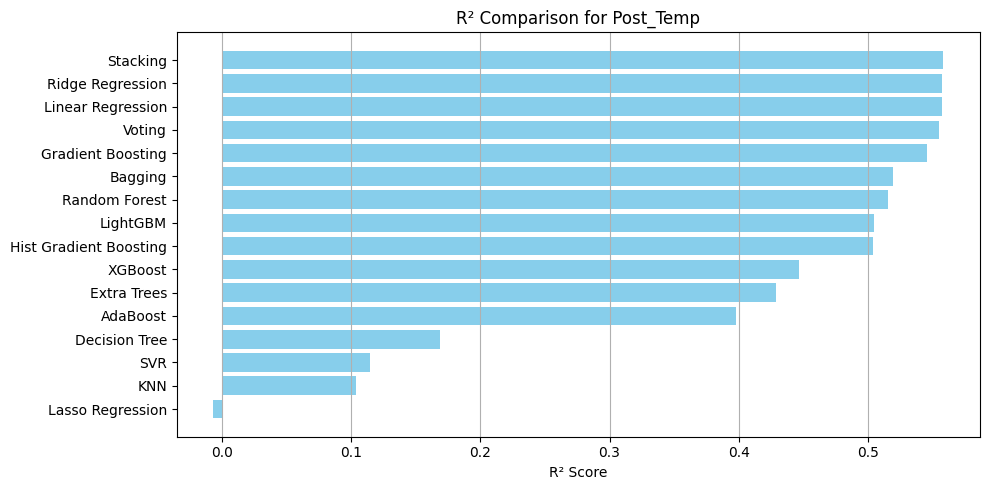

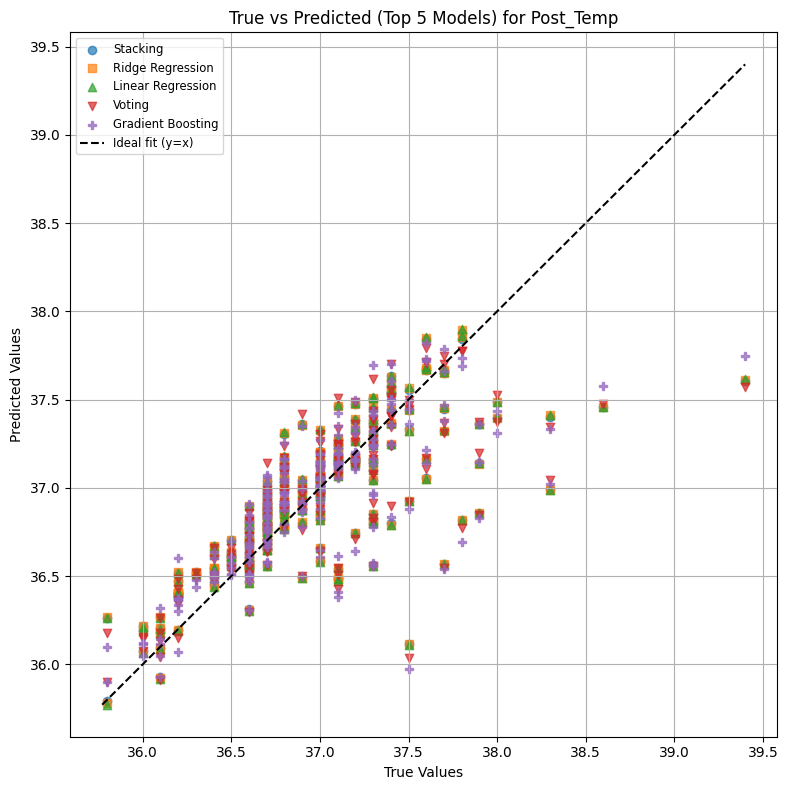

In [22]:
# Evaluate & plot for Post_SBP
evaluate_and_plot_models(X_train_sbp, X_test_sbp, y_train_sbp, y_test_sbp, "Post_SBP")

# Evaluate & plot for Post_Temp
evaluate_and_plot_models(X_train_temp, X_test_temp, y_train_temp, y_test_temp, "Post_Temp")


Explainability for the Models

LIME

Generating LIME explanation for Linear Regression on Post_SBP (test sample index 5)...


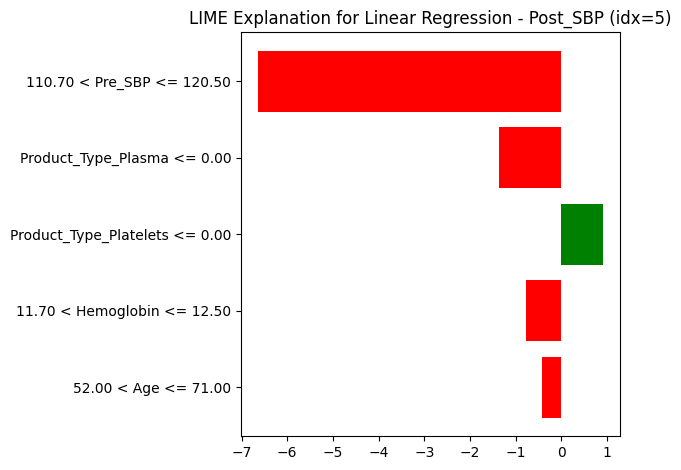

Generating LIME explanation for Ridge Regression on Post_SBP (test sample index 5)...


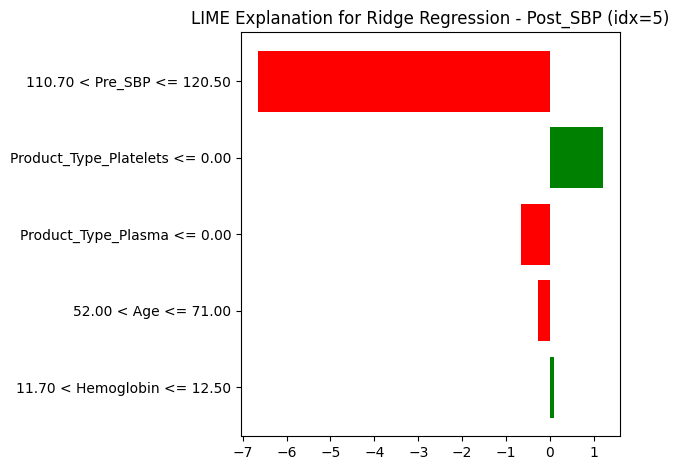

Generating LIME explanation for Lasso Regression on Post_SBP (test sample index 5)...


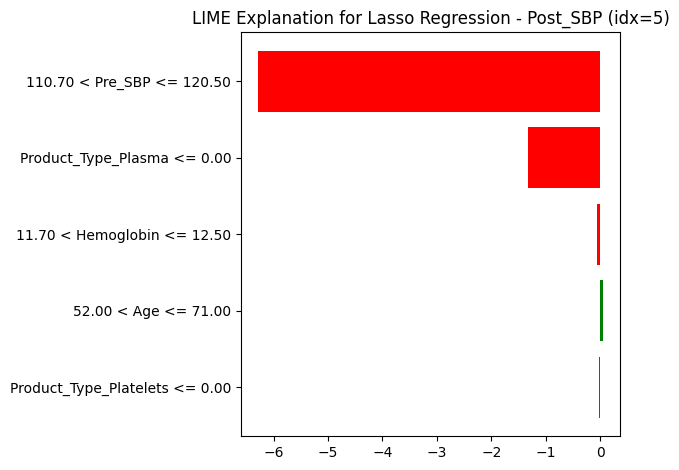

Generating LIME explanation for Decision Tree on Post_SBP (test sample index 5)...


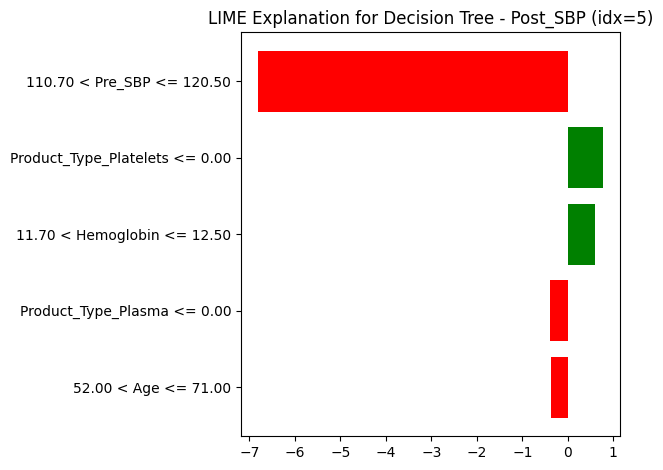

Generating LIME explanation for Random Forest on Post_SBP (test sample index 5)...


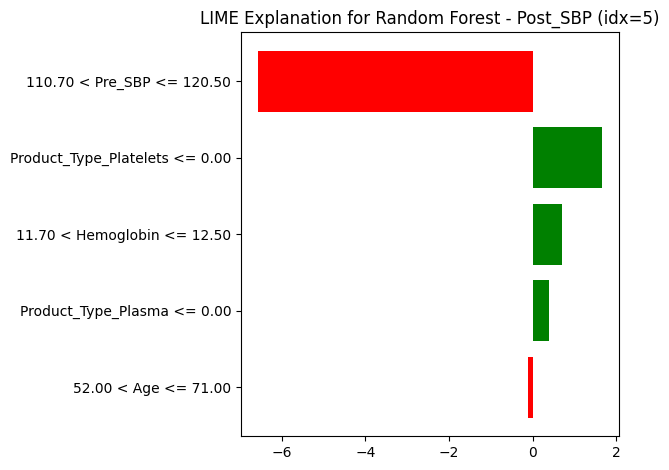

Generating LIME explanation for Gradient Boosting on Post_SBP (test sample index 5)...


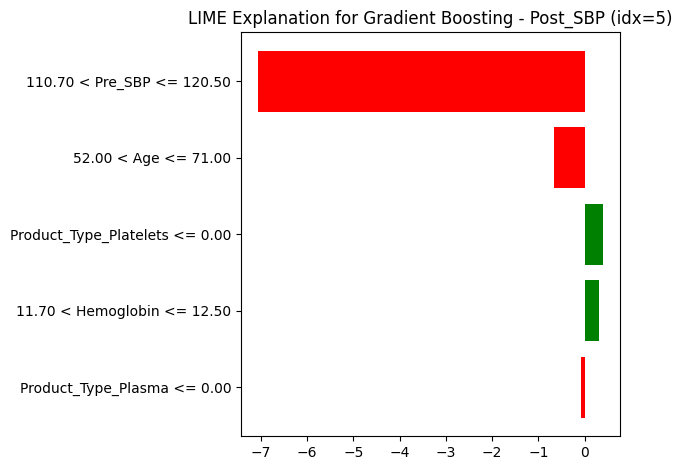

Generating LIME explanation for Hist Gradient Boosting on Post_SBP (test sample index 5)...


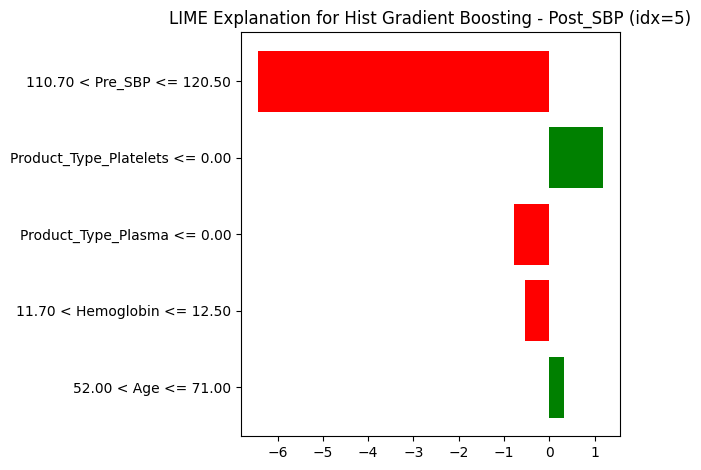

Generating LIME explanation for AdaBoost on Post_SBP (test sample index 5)...


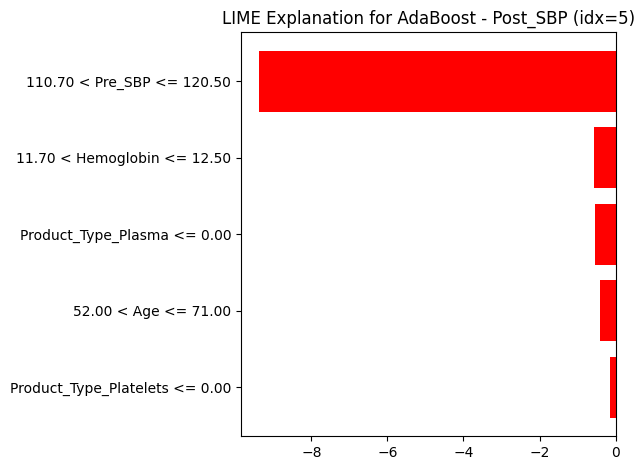

Generating LIME explanation for KNN on Post_SBP (test sample index 5)...


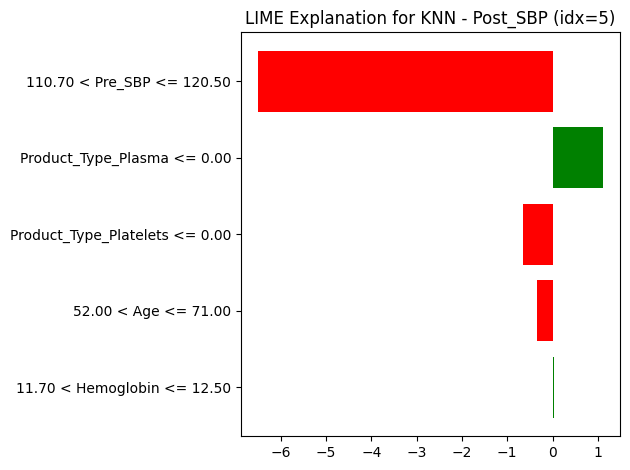

Generating LIME explanation for SVR on Post_SBP (test sample index 5)...


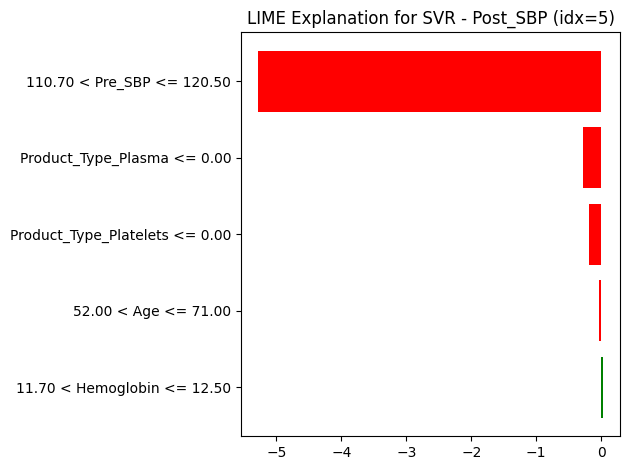

Generating LIME explanation for XGBoost on Post_SBP (test sample index 5)...


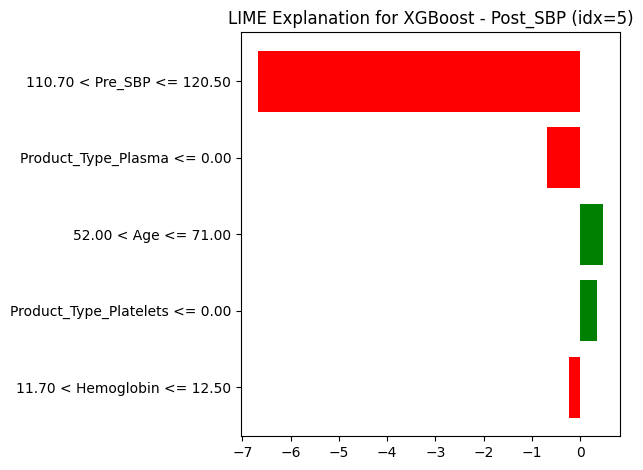

Generating LIME explanation for Bagging on Post_SBP (test sample index 5)...


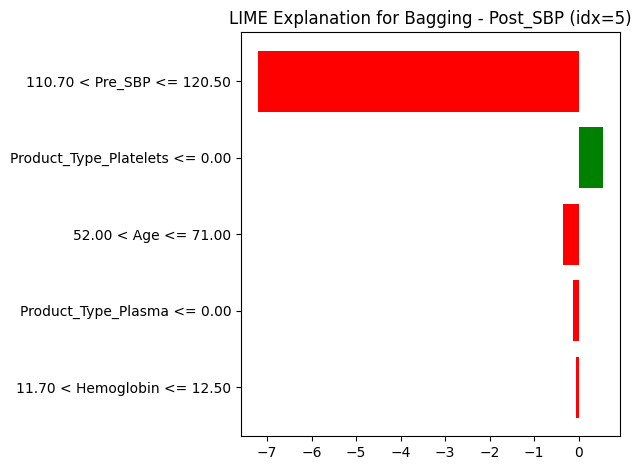

Generating LIME explanation for Extra Trees on Post_SBP (test sample index 5)...


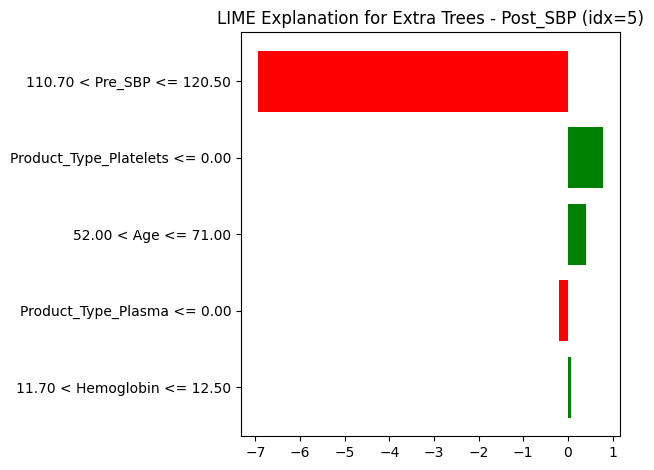

Generating LIME explanation for Stacking on Post_SBP (test sample index 5)...


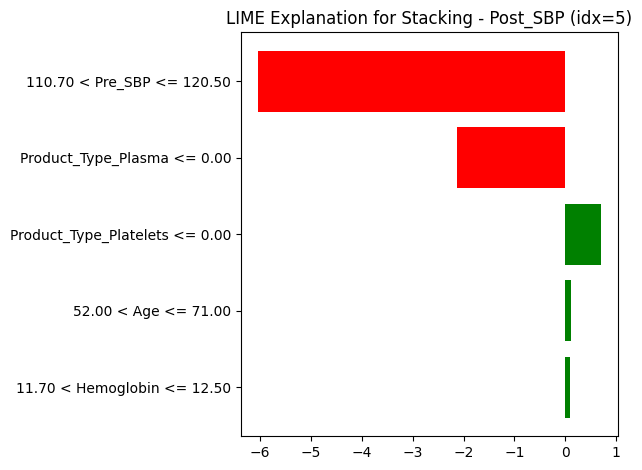

Generating LIME explanation for Voting on Post_SBP (test sample index 5)...


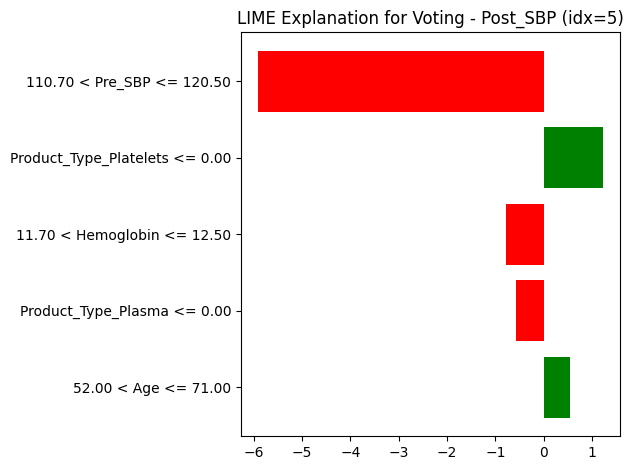

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 388
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 5
[LightGBM] [Info] Start training from score 119.362750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

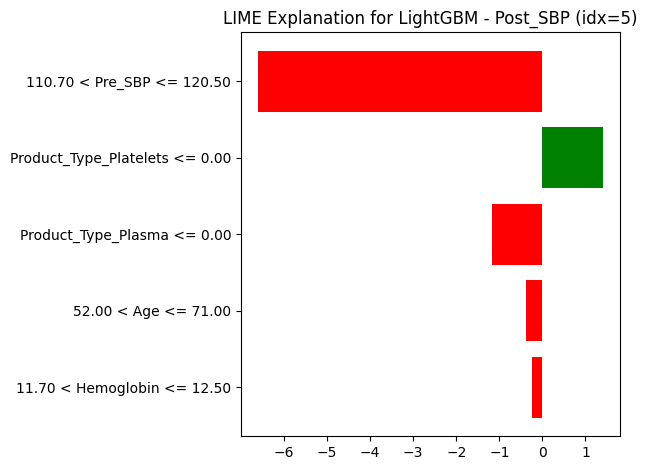

Generating LIME explanation for Linear Regression on Post_Temp (test sample index 5)...


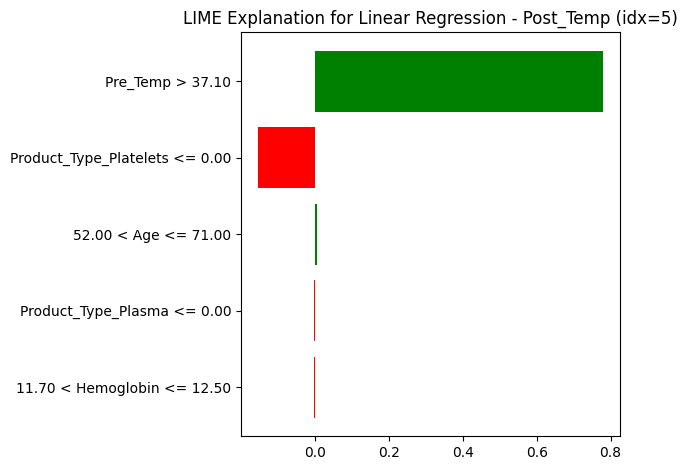

Generating LIME explanation for Ridge Regression on Post_Temp (test sample index 5)...


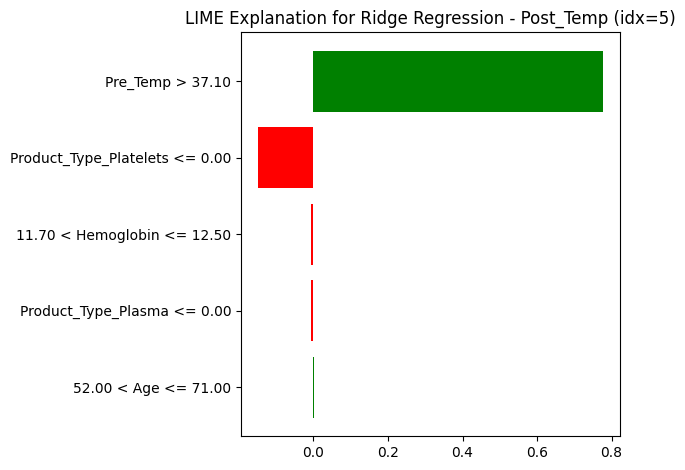

Generating LIME explanation for Lasso Regression on Post_Temp (test sample index 5)...


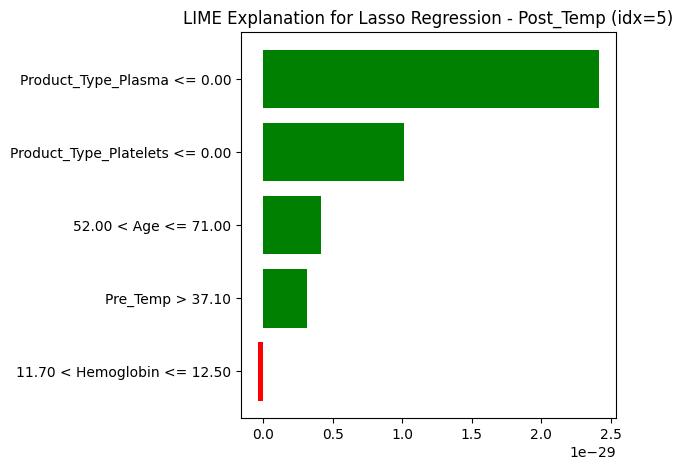

Generating LIME explanation for Decision Tree on Post_Temp (test sample index 5)...


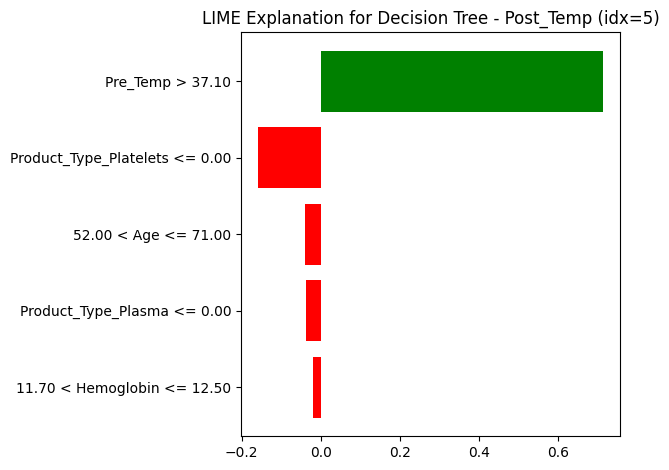

Generating LIME explanation for Random Forest on Post_Temp (test sample index 5)...


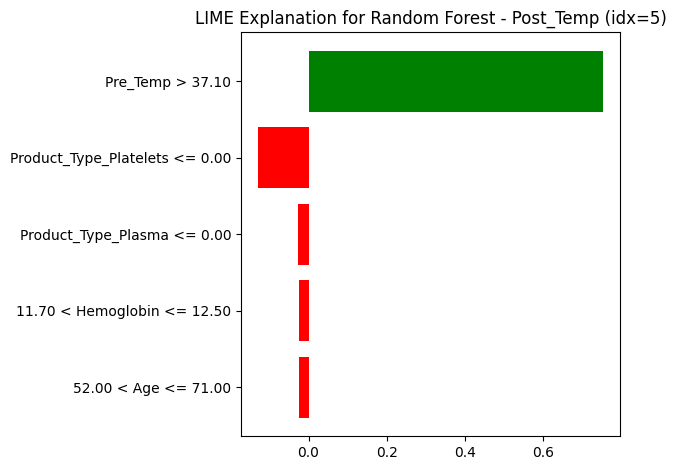

Generating LIME explanation for Gradient Boosting on Post_Temp (test sample index 5)...


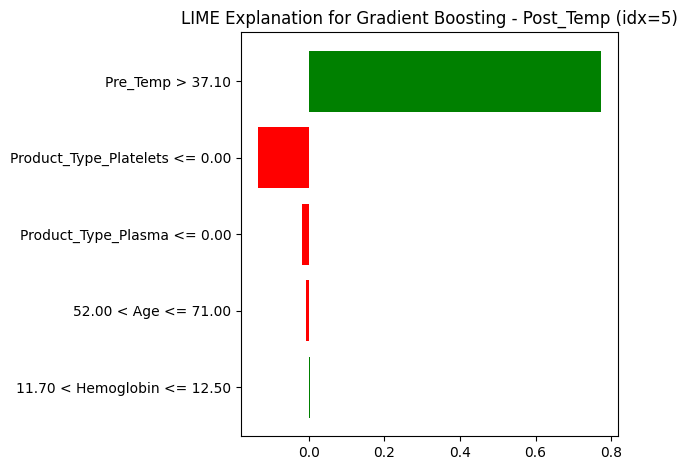

Generating LIME explanation for Hist Gradient Boosting on Post_Temp (test sample index 5)...


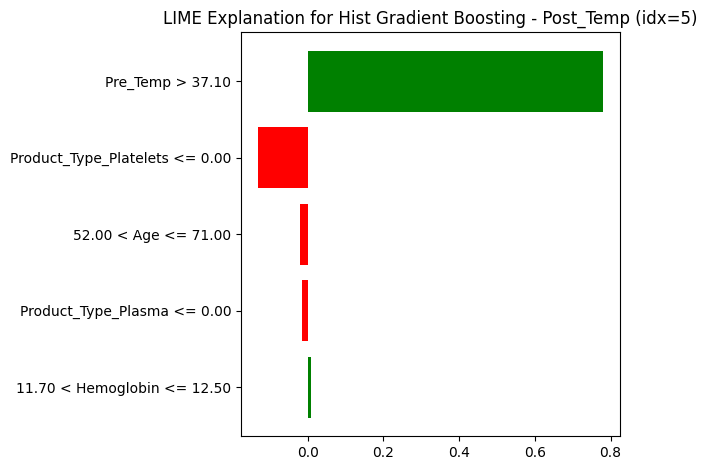

Generating LIME explanation for AdaBoost on Post_Temp (test sample index 5)...


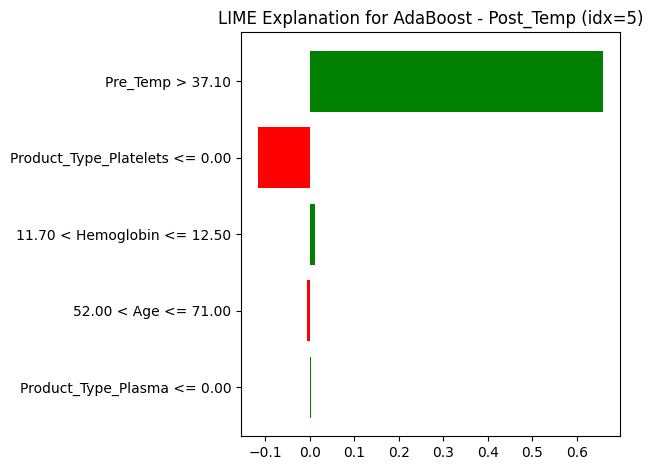

Generating LIME explanation for KNN on Post_Temp (test sample index 5)...


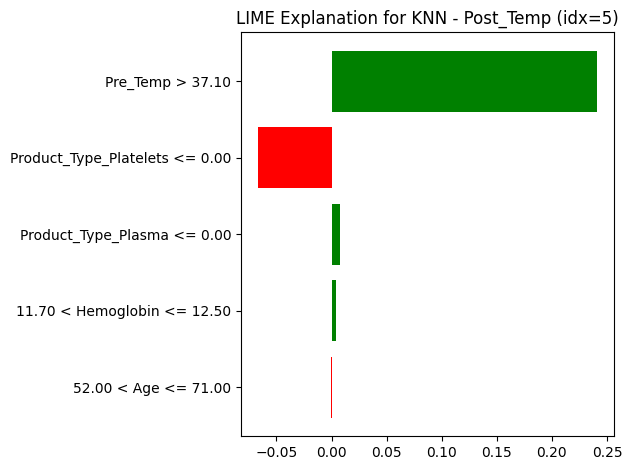

Generating LIME explanation for SVR on Post_Temp (test sample index 5)...


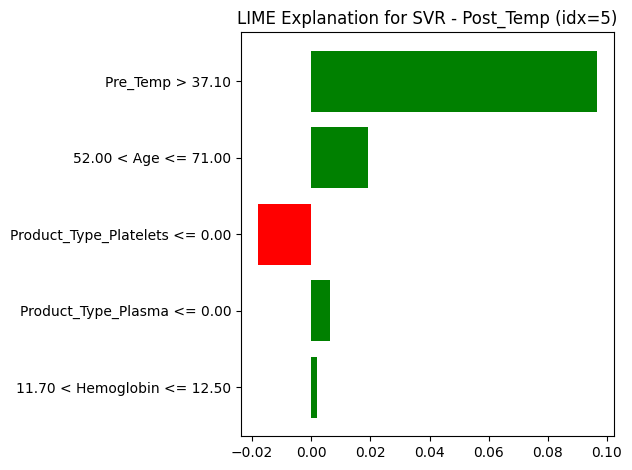

Generating LIME explanation for XGBoost on Post_Temp (test sample index 5)...


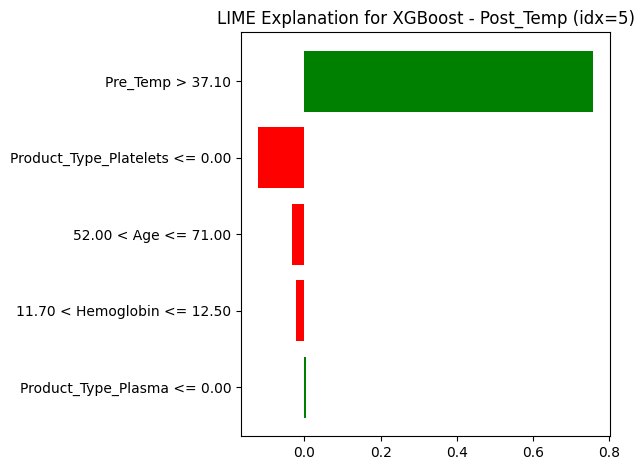

Generating LIME explanation for Bagging on Post_Temp (test sample index 5)...


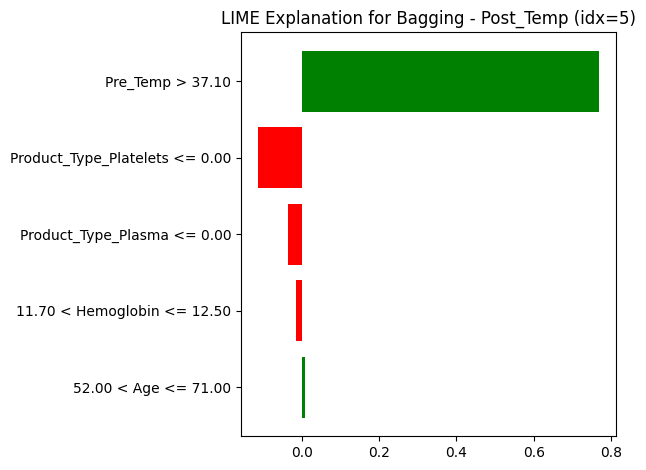

Generating LIME explanation for Extra Trees on Post_Temp (test sample index 5)...


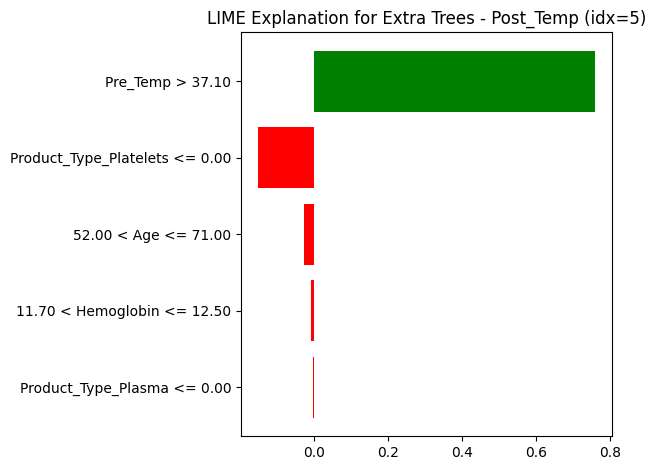

Generating LIME explanation for Stacking on Post_Temp (test sample index 5)...


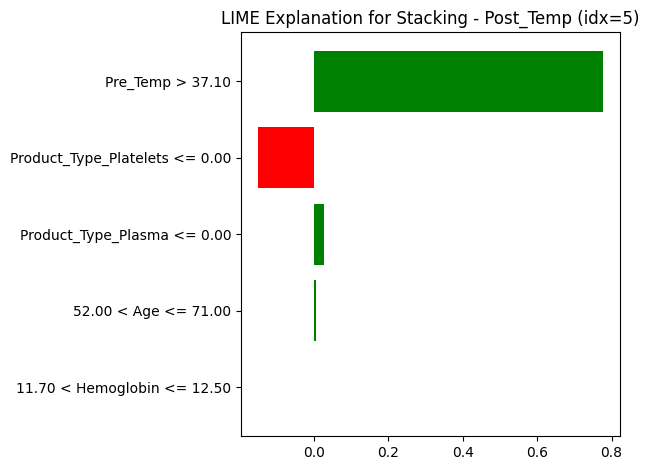

Generating LIME explanation for Voting on Post_Temp (test sample index 5)...


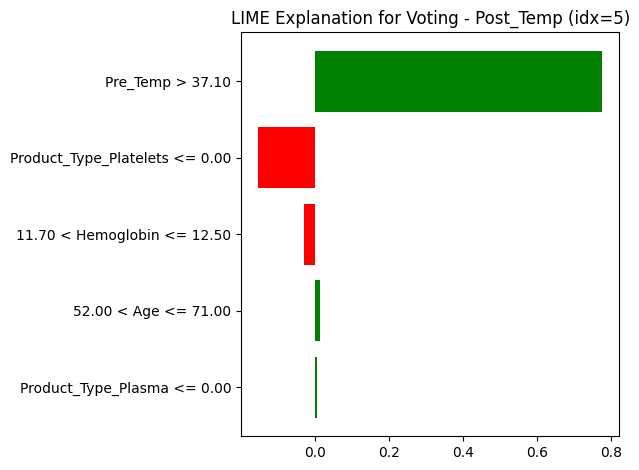

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000039 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 158
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 5
[LightGBM] [Info] Start training from score 36.920750
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

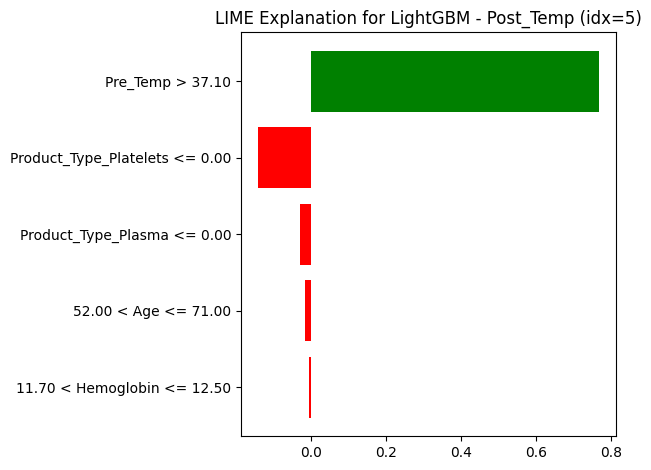

In [29]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

def explain_with_lime(model_name, model, X_train, X_test, idx, target_name):
    print(f"Generating LIME explanation for {model_name} on {target_name} (test sample index {idx})...")
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=np.array(X_train),
        feature_names=X_train.columns,
        mode='regression'
    )
    exp = lime_explainer.explain_instance(
        data_row=X_test.iloc[idx],
        predict_fn=model.predict
    )
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation for {model_name} - {target_name} (idx={idx})")
    plt.tight_layout()
    plt.savefig(f"lime_{target_name}_{model_name.replace(' ', '_')}_idx{idx}.png")
    plt.show()

# Choose the test sample index for explanation
idx = 5

# Explain all models for Post_SBP
for name, model in models.items():
    model.fit(X_train_sbp, y_train_sbp)
    explain_with_lime(name, model, X_train_sbp, X_test_sbp, idx, "Post_SBP")

# Explain all models for Post_Temp
for name, model in models.items():
    model.fit(X_train_temp, y_train_temp)
    explain_with_lime(name, model, X_train_temp, X_test_temp, idx, "Post_Temp")


SAHP Explanations for the follosing Models:


*   Random Forest
*   Gradient Boosting,
*   Histogram Gradient Boosting  
*   XGBoost



Generating SHAP plots for selected Post_SBP models...
Processing Random Forest...


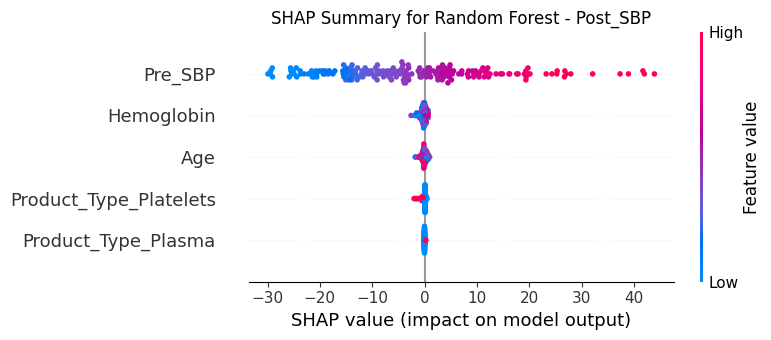

Processing Gradient Boosting...


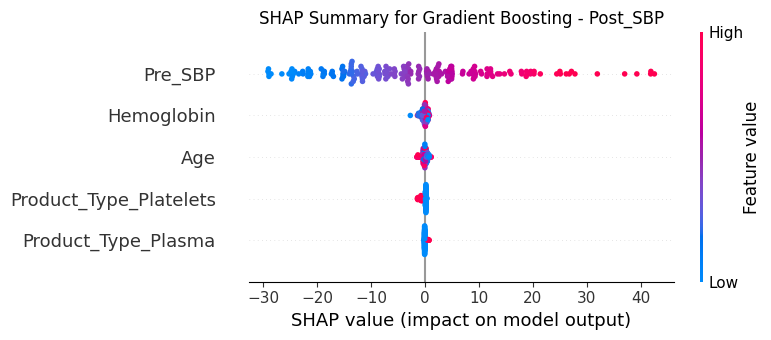

Processing Hist Gradient Boosting...


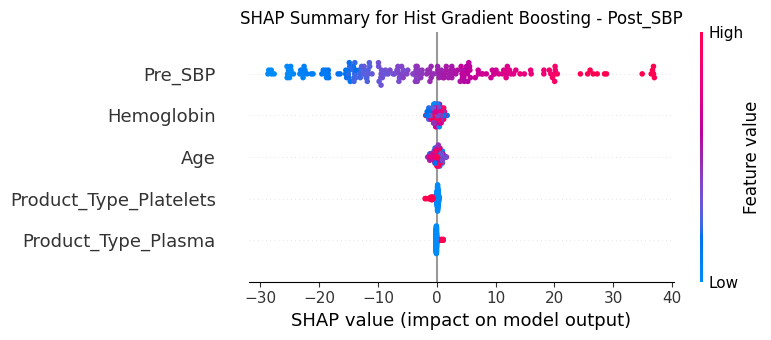

Processing XGBoost...


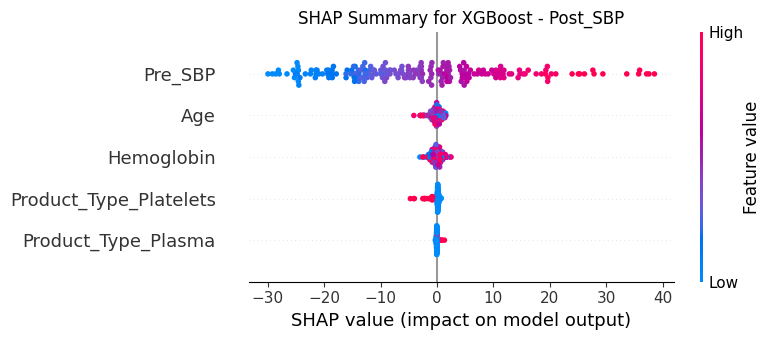

Generating SHAP plots for selected Post_Temp models...
Processing Random Forest...


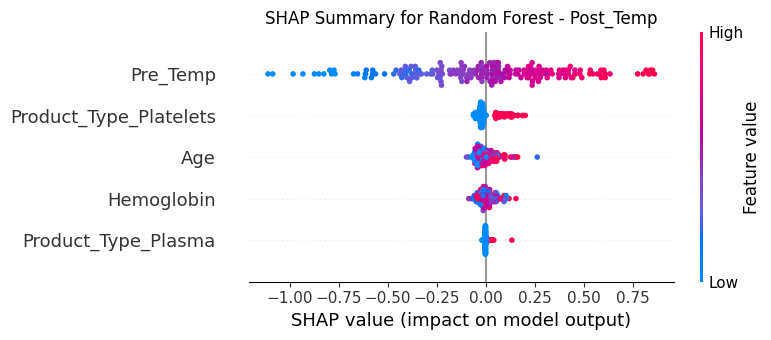

Processing Gradient Boosting...


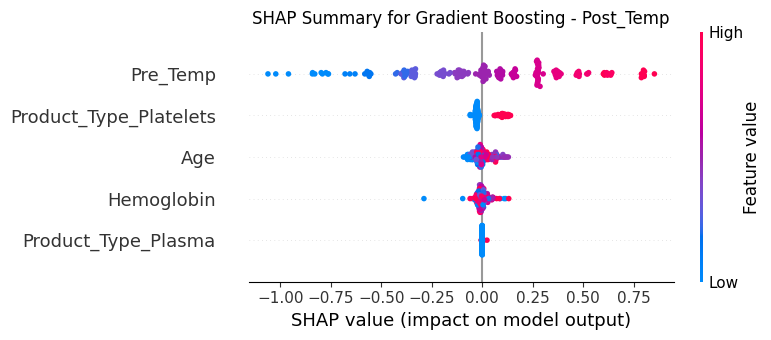

Processing Hist Gradient Boosting...


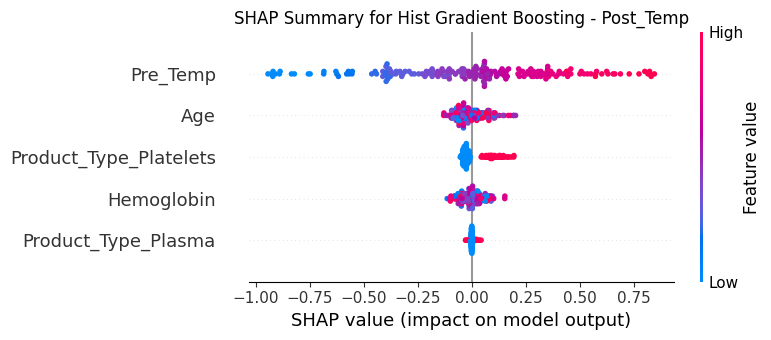

Processing XGBoost...


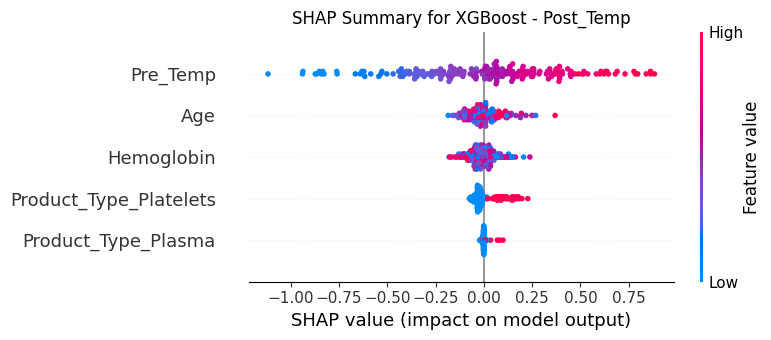

In [34]:
import shap
import matplotlib.pyplot as plt
import numpy as np

from lightgbm import LGBMRegressor

# Define the subset of tree-based models you want to explain
tree_models = [
    'Random Forest',
    'Gradient Boosting',
    'Hist Gradient Boosting',
    'XGBoost'
]

def get_shap_explainer(model):
    # Always use TreeExplainer for these models
    return shap.TreeExplainer(model)

# SHAP for Post_SBP models
print("Generating SHAP plots for selected Post_SBP models...")
for name, model in models.items():
    if name in tree_models:
        print(f"Processing {name}...")
        model.fit(X_train_sbp, y_train_sbp)
        explainer = get_shap_explainer(model)

        shap_values = explainer.shap_values(X_test_sbp)

        plt.figure()
        shap.summary_plot(shap_values, X_test_sbp, show=False, feature_names=X_train_sbp.columns)
        plt.title(f"SHAP Summary for {name} - Post_SBP")
        plt.tight_layout()
        plt.savefig(f"shap_summary_Post_SBP_{name.replace(' ', '_')}.png")
        plt.show()

# SHAP for Post_Temp models
print("Generating SHAP plots for selected Post_Temp models...")
for name, model in models.items():
    if name in tree_models:
        print(f"Processing {name}...")
        model.fit(X_train_temp, y_train_temp)
        explainer = get_shap_explainer(model)

        shap_values = explainer.shap_values(X_test_temp)

        plt.figure()
        shap.summary_plot(shap_values, X_test_temp, show=False, feature_names=X_train_temp.columns)
        plt.title(f"SHAP Summary for {name} - Post_Temp")
        plt.tight_layout()
        plt.savefig(f"shap_summary_Post_Temp_{name.replace(' ', '_')}.png")
        plt.show()
